In [3]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set plotting style
# In Matplotlib 3.6+, the seaborn style was removed, so seaborn-v0_8 was used instead.
plt.style.use('seaborn-v0_8')
sns.set_palette('deep')

# Connect to the SQLite database
conn = sqlite3.connect('papcorns.sqlite')

# Load users table
users_df = pd.read_sql_query("SELECT * FROM users;", conn)

# Load events table
events_df = pd.read_sql_query("SELECT * FROM user_events;", conn)

#Time convert
users_df["created_at"] = pd.to_datetime(users_df["created_at"])
events_df["created_at"] = pd.to_datetime(events_df["created_at"])

#Analyze tables
def check_df(dataframe, head=5):
    print("##################### Shape #####################")
    print(dataframe.shape)
    print("##################### Types #####################")
    print(dataframe.dtypes)
    print("##################### Head #####################")
    print(dataframe.head(head))
    print("##################### Tail #####################")
    print(dataframe.tail(head))
    print("##################### NA #####################")
    print(dataframe.isnull().sum())
    print("##################### NUnique #####################")
    print(dataframe.nunique())
    print("##################### Unique #####################")
    cat_cols = [col for col in dataframe.columns
                if pd.api.types.is_object_dtype(dataframe[col])
                or pd.api.types.is_string_dtype(dataframe[col])]
    # cat_but_car: object/string columns with many unique values
    # These are categorical-like but not useful as normal categories because they are almost unique (e.g. name, id)
    cat_but_car = [col for col in dataframe.columns
                   if dataframe[col].nunique() > 20
                   and (pd.api.types.is_object_dtype(dataframe[col])
                        or pd.api.types.is_string_dtype(dataframe[col]))]

    # update cat_cols
    cat_cols = [col for col in cat_cols if col not in cat_but_car]
    for col in cat_cols:
        print(f"{col}: {dataframe[col].unique().tolist()}")

print("###user_df###")
check_df(users_df)

print("###events_df###")
check_df(events_df)


###user_df###
##################### Shape #####################
(1002, 5)
##################### Types #####################
id                             int64
created_at            datetime64[us]
attribution_source               str
country                          str
name                             str
dtype: object
##################### Head #####################
   id created_at attribution_source country          name
0   1 2024-05-07          instagram      US     Eve Brown
1   2 2024-10-12          instagram      NL   Frank Moore
2   3 2024-10-15             tiktok      TR  Ivy Anderson
3   4 2024-08-28             tiktok      TR   Alice Brown
4   5 2024-04-03            organic      NL     Bob Moore
##################### Tail #####################
        id created_at attribution_source country           name
997    998 2025-02-01          instagram      TR      Bob Davis
998    999 2024-12-24            organic      NL  Charlie Davis
999   1000 2025-02-13            organi


# **Data Understanding & Initial Exploration**

In the initial stage, datasets were examined, data types were verified, and missing value/data distribution analyses were conducted. During the analysis process, the users and user_events tables were transferred from the SQLite database to the Python environment.

## **Users Table Analysis**

The users table consists of 1,002 users and 5 variables. There are no missing values in the dataset. The created_at variable has been converted to datetime format to make it suitable for time-based analysis.

**_Findings from the examination:_**

**Attribution Sources:** It was observed that user acquisition sources (attribution_source) contain three different categories: Instagram, TikTok, and Organic.

**Geographic Distribution:** Users originate from three different countries: US, NL, and TR.

**Cardinality**: The name variable was found to have high cardinality (1,002 distinct values). Consequently, it was not used in categorical analysis and was only evaluated for user identification purposes.


## **User Events Table Analysis**

The user_events table consists of a total of 3,486 event records. This table tracks user behavior on an event basis.

**_Findings from the examination:_**

**Event Types:** The event_name variable contains 6 different event types:
app_install
trial_started
trial_cancelled
subscription_started
subscription_renewed
subscription_cancelled

**Missing Values:** There are 2,255 missing values in the amount_usd column. This is because only subscription events generate revenue, while other event types do not contain pricing information. This is expected behavior and is not considered a data quality issue.

**Pricing Structure:** Only 3 different price values were observed in the amount_usd variable, suggesting that the platform utilizes a limited number of subscription plans.


## General Observations

The two tables are linked via the user_id field. The data structure is suitable for user-based behavior analysis, conversion funnel analysis, revenue analysis, and lifetime value (LTV) modeling.

Furthermore, the event flow in the dataset supports the following user lifecycle:

app_install → trial_started → subscription_started → renewal/cancellation

In [15]:
#1 Calculate the total revenue generated from subscriptions for each country
sub_country_revenue = pd.read_sql_query("""
    SELECT
        U.country,
        SUM(E.amount_usd) AS total_revenue
    FROM user_events E
    INNER JOIN users U
        ON E.user_id = U.id
--Although other events currently have 0 revenue,
--subscription events were explicitly filtered to ensure
--accurate revenue calculation and to handle potential
--future revenue-generating event types.
    WHERE U.event_name IN (
        'subscription_started',
        'subscription_renewed'
    )
    GROUP BY U.country
    ORDER BY total_revenue DESC
""", conn)

print(f"First task answer:\n{sub_country_revenue.to_string(index=False)}")


Event types and amount usd
               event_name  amount_usd
0             app_install         NaN
1  subscription_cancelled         NaN
2    subscription_renewed     5845.50
3    subscription_started     3801.19
4         trial_cancelled         NaN
5           trial_started         NaN
First task answer:
country  total_revenue
     US        4035.96
     NL        3335.29
     TR        2275.44


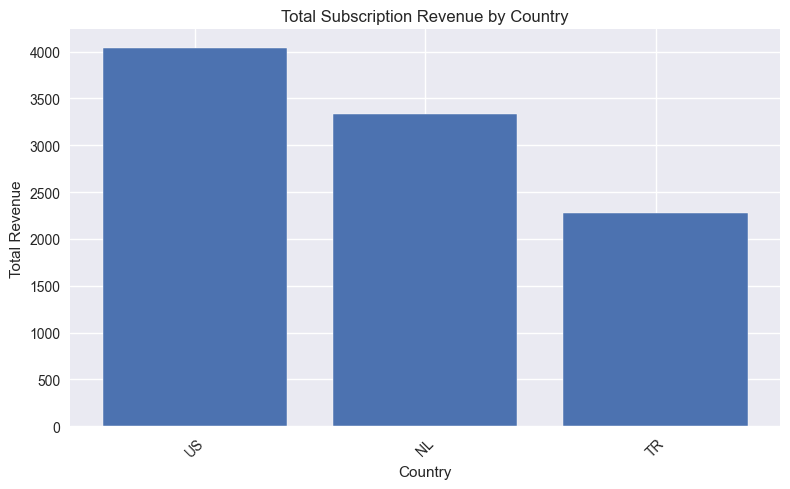

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    sub_country_revenue["country"],
    sub_country_revenue["total_revenue"]
)

plt.title("Total Subscription Revenue by Country")
plt.xlabel("Country")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


### **Analysis**

The highest revenue was generated from US users.
NL showed strong monetization performance and produced results close to the US.
TR generated lower revenue compared to the other countries. This may be caused by lower conversion or retention rates.
Only subscription events were included in the revenue analysis because other event types do not contain revenue information.

In [20]:
#2 Calculate the total number of trials given to users who came from Instagram.
insta_trial = pd.read_sql_query("""
    SELECT COUNT(*) AS total_trials
    FROM user_events E
    INNER JOIN users U
        ON E.user_id = U.id
    WHERE U.attribution_source = 'instagram'
      AND E.event_name = 'trial_started'
""", conn)

print(f"Second task answer:\n{insta_trial.to_string(index=False)}")

Second task answer:
 total_trials
          210



### **Finding:**

Instagram users generated a total of 210 trial starts, making Instagram one of the major acquisition channels for trial engagement.

### **Analysis:**

This result indicates that Instagram campaigns are effective at attracting users to try the product. However, trial volume alone is not enough to evaluate performance fully; conversion quality should also be analyzed through the trial-to-subscription conversion rate.

In [4]:
#3 Create a new column named 'acquisition_channel' by categorizing users based on their 'attribution_source':
#'Paid': users from instagram or tiktok
#'Organic': users from organic sources
user_cat= pd.read_sql_query("""
    SELECT * ,
        CASE WHEN attribution_source IN ('instagram','tiktok') THEN 'Paid'
             WHEN attribution_source = 'organic' THEN 'Organic'
             ELSE 'Other' END AS acquisition_channel
    FROM users
""", conn)

print(user_cat[:5])

   id           created_at attribution_source country          name  \
0   1  2024-05-07T00:00:00          instagram      US     Eve Brown   
1   2  2024-10-12T00:00:00          instagram      NL   Frank Moore   
2   3  2024-10-15T00:00:00             tiktok      TR  Ivy Anderson   
3   4  2024-08-28T00:00:00             tiktok      TR   Alice Brown   
4   5  2024-04-03T00:00:00            organic      NL     Bob Moore   

  acquisition_channel  
0                Paid  
1                Paid  
2                Paid  
3                Paid  
4             Organic  


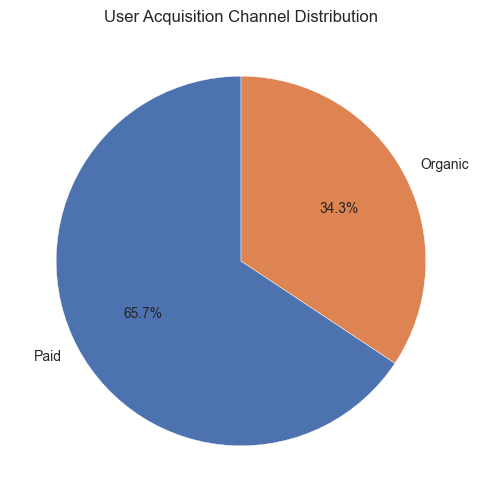

In [5]:
import matplotlib.pyplot as plt

channel_counts = user_cat["acquisition_channel"].value_counts()
plt.figure(figsize=(6,6))

plt.pie(
    channel_counts,
    labels=channel_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("User Acquisition Channel Distribution")

plt.show()

### **Finding:**

Approximately 65% of users were acquired through paid channels (Instagram and TikTok), while 34% came from organic sources.

### **Analysis:**

The user base is primarily driven by paid acquisition channels, showing that marketing campaigns play a major role in user growth. Organic acquisition still represents a significant share, indicating existing brand visibility and user-driven discovery

In [50]:
#4 Analyze the trial-to-subscription conversion rate:
#Calculate the overall conversion rate
#Break down the conversion rate by attribution_source

# overall: conv / trials
conv_rate= pd.read_sql_query("""
WITH TRIALS AS (
    SELECT DISTINCT user_id
    FROM user_events
    WHERE event_name= 'trial_started'
),
CONVERSION AS (
    SELECT DISTINCT user_id
    FROM user_events
    WHERE event_name= 'subscription_started'
)
SELECT COUNT(C.user_id) total_conversion, COUNT(T.user_id) total_trial,
       COUNT(C.user_id)* 1.0 /COUNT(T.user_id) conversion_rate
FROM TRIALS T
LEFT JOIN CONVERSION C ON T.user_id= C.user_id
                             """, conn)
print(f'Conversion rate \n {conv_rate}')

conv_by_source = pd.read_sql_query("""
    WITH trials AS (
        SELECT DISTINCT
            E.user_id,
            U.attribution_source
        FROM user_events E
        INNER JOIN users U
            ON E.user_id = U.id
        WHERE E.event_name = 'trial_started'
    ),
    conversions AS (
        SELECT DISTINCT user_id
        FROM user_events
        WHERE event_name = 'subscription_started'
    )

    SELECT
        t.attribution_source,
        --Multiplying by 1.0 converts the value to float,
        COUNT(DISTINCT c.user_id) * 1.0 / COUNT(DISTINCT t.user_id) AS conversion_rate
    FROM trials t
    LEFT JOIN conversions c
        ON t.user_id = c.user_id
    GROUP BY t.attribution_source
""", conn)

print(f'Conversion rate with sources \n {conv_by_source}')

Conversion rate 
    total_conversion  total_trial  conversion_rate
0               481          682         0.705279
Conversion rate with sources 
   attribution_source  conversion_rate
0          instagram         0.709524
1            organic         0.716102
2             tiktok         0.690678



### **Finding:**

The overall trial-to-subscription conversion rate is approximately 70.5%, indicating that a large proportion of trial users eventually become paying subscribers.

By attribution source:

Organic: 71.6%
Instagram: 70.9%
TikTok: 69.1%

### **Analysis:**

All acquisition channels show relatively similar conversion performance, with organic users having the highest conversion rate. This suggests that organically acquired users may have slightly higher purchase intent or stronger product interest compared to paid channels. TikTok has the lowest conversion rate among the three sources, although the difference is not substantial.

In [51]:
# 6 Calculate the median subscription duration (in months) for each country

# Step 1: For each user, get first subscription start and cancel date
# Step 2: Compute duration in days using julianday()
# Step 3: Convert days -> months (/30)
# Step 4: Take median duration per country
# Note: median is used to reduce effect of extreme values

duration_df = pd.read_sql_query("""
    WITH subscription_dates AS (
        SELECT E.user_id, U.country,
            MIN(CASE WHEN E.event_name = 'subscription_started' THEN E.created_at END
            ) AS start_date,
            MIN(CASE WHEN E.event_name = 'subscription_cancelled' THEN E.created_at END
            ) AS cancel_date
        FROM user_events E
        INNER JOIN users U ON E.user_id = U.id
        GROUP BY E.user_id, U.country
    )

    SELECT country,
        ( julianday(cancel_date) - julianday(start_date)
        ) / 30.0 AS duration_months

    FROM subscription_dates
    WHERE start_date IS NOT NULL
      AND cancel_date IS NOT NULL
""", conn)

median_duration = (
    duration_df
    .groupby("country")["duration_months"]
    .median()
    .reset_index()
)

print(median_duration)

  country  duration_months
0      NL         2.316667
1      TR         2.533333
2      US         2.266667


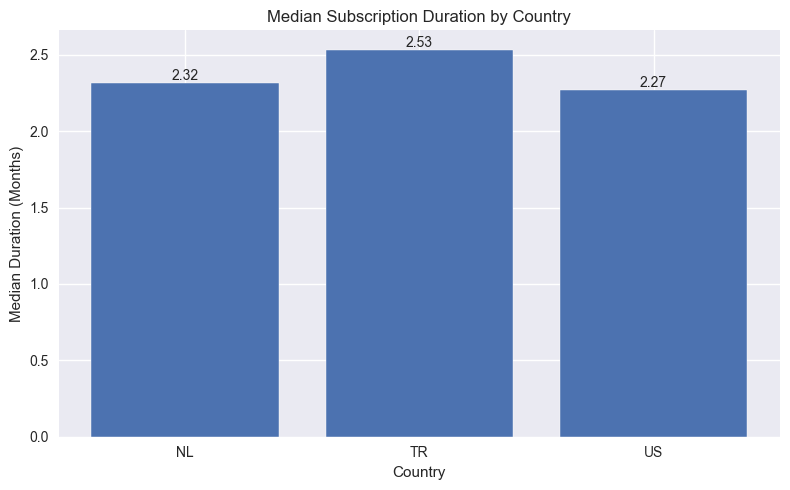

In [54]:
# Visualization - Median Subscription Duration by Country

plt.figure(figsize=(8,5))

bars = plt.bar(
    median_duration["country"],
    median_duration["duration_months"]
)

plt.title("Median Subscription Duration by Country")
plt.xlabel("Country")
plt.ylabel("Median Duration (Months)")

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()

In [56]:
# 6 Calculate the Average Lifetime Value (LTV) by country

#LTV = total subscription revenue / total paying users
ltv_by_country = pd.read_sql_query("""
    SELECT U.country, ROUND( SUM(E.amount_usd) * 1.0 / COUNT(DISTINCT E.user_id), 2
        ) AS avg_ltv
    FROM user_events E
    INNER JOIN users U ON E.user_id = U.id
    WHERE E.event_name IN (
        'subscription_started',
        'subscription_renewed'
    )
    GROUP BY U.country
    ORDER BY avg_ltv DESC
""", conn)

print(ltv_by_country)

  country  avg_ltv
0      US    25.07
1      NL    22.38
2      TR    13.31


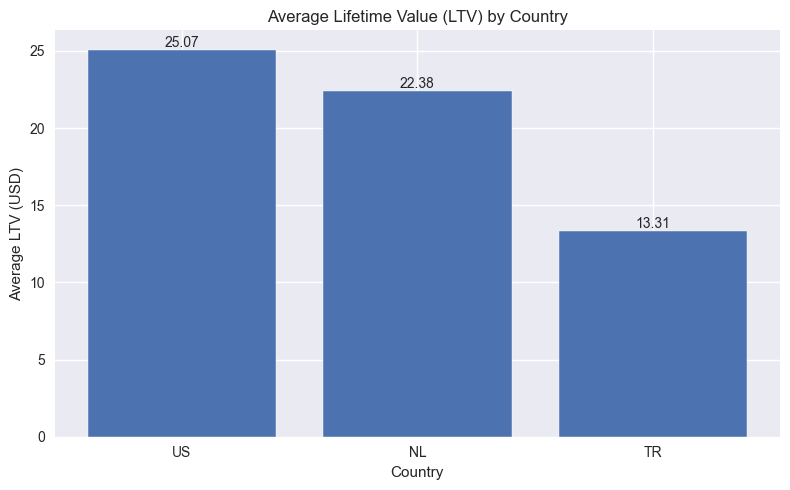

In [57]:
plt.figure(figsize=(8,5))

bars = plt.bar(
    ltv_by_country["country"],
    ltv_by_country["avg_ltv"]
)

plt.title("Average Lifetime Value (LTV) by Country")
plt.xlabel("Country")
plt.ylabel("Average LTV (USD)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha='center',
        va='bottom'
    )

plt.tight_layout()
plt.show()


### **Finding:**

The median subscription duration is relatively similar across all countries:

TR: 2.53 months
NL: 2.32 months
US: 2.27 months

### **Analysis:**

Users from Türkiye show the longest median subscription duration, which may indicate slightly stronger retention behavior compared to the Netherlands and the US. However, the differences between countries are relatively small, suggesting that subscription retention patterns are generally consistent across regions.